In [ ]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Открываем датафрейм
df = pd.read_csv('Global YouTube Statistics.csv', encoding = 'windows-1252')
df

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Natan por Aï¿,12300000,9.029610e+09,Sports,Natan por Aï¿,1200,Brazil,BR,Entertainment,...,700000.0,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,Free Fire India Official,12300000,1.674410e+09,People & Blogs,Free Fire India Official,1500,India,IN,Games,...,300000.0,2018.0,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,Panda,12300000,2.214684e+09,NaN,HybridPanda,2452,United Kingdom,GB,Games,...,1000.0,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,RobTopGames,12300000,3.741235e+08,Gaming,RobTopGames,39,Sweden,SE,Games,...,100000.0,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


#**Задание 1. EDA**
* Проведите разведывательный анализ данных (EDA).
* Задайте не менее 6 вопросов к данным и постарайтесь ответить на них, используя визуализацию.
* Изобразите матрицу корреляций для нахождения взаимосвязей

##EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   Title                                    995 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    object 
 8   Abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [ ]:
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,...,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,...,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,...,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [ ]:
df.isna().sum()

,0
rank,0
Youtuber,0
subscribers,0
video views,0
category,46
Title,0
uploads,0
Country,122
Abbreviation,122
channel_type,30


###Работа с пропусками

In [ ]:
#Используем функцию для заполнения NaN-значений в связанных между собой столбцах
def fill_val(trgt_val, sprt_val):
  existing_val = df.dropna(subset=[trgt_val]).set_index(sprt_val)[trgt_val].to_dict()
  df[trgt_val] = df[trgt_val].fillna(df[sprt_val].map(existing_val))

In [ ]:
fill_val('Country', 'country_rank')
fill_val('country_rank', 'Country')
fill_val('Country', 'Abbreviation')
fill_val('Abbreviation', 'Country')
fill_val('channel_type_rank', 'channel_type')
fill_val('channel_type', 'channel_type_rank')

In [ ]:
df.isna().sum()

,0
rank,0
Youtuber,0
subscribers,0
video views,0
category,46
Title,0
uploads,0
Country,0
Abbreviation,0
channel_type,30


In [ ]:
df_clean = df.dropna(subset = ['Latitude'])
df_clean

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Natan por Aï¿,12300000,9.029610e+09,Sports,Natan por Aï¿,1200,Brazil,BR,Entertainment,...,700000.0,2017.0,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,Free Fire India Official,12300000,1.674410e+09,People & Blogs,Free Fire India Official,1500,India,IN,Games,...,300000.0,2018.0,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,Panda,12300000,2.214684e+09,NaN,HybridPanda,2452,United Kingdom,GB,Games,...,1000.0,2006.0,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,RobTopGames,12300000,3.741235e+08,Gaming,RobTopGames,39,Sweden,SE,Games,...,100000.0,2012.0,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


In [ ]:
# Статистика значительно исказилась
# Игнорируем пропуски
df_clean.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,872.000000,8.720000e+02,8.720000e+02,872.000000,8.710000e+02,872.000000,865.000000,8.500000e+02,872.000000,8.720000e+02,...,8.720000e+02,5.970000e+02,869.000000,869.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,505.238532,2.285573e+07,1.123485e+10,10407.905963,2.744603e+05,384.827982,432.230058,1.823042e+08,39242.173337,6.274127e+05,...,7.534467e+06,3.519155e+05,2012.475259,15.531646,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.342702,1.784798e+07,1.479528e+10,36314.507739,9.768543e+05,1232.860440,1403.988427,4.275247e+08,72942.346581,1.166045e+06,...,1.400488e+07,6.118783e+05,4.418843,8.878233,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.000000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,260.750000,1.447500e+07,4.254150e+09,291.750000,2.875000e+02,11.750000,25.000000,2.563825e+07,4875.000000,7.827500e+04,...,9.389750e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,511.500000,1.755000e+07,7.712618e+09,875.500000,8.060000e+02,51.000000,61.000000,7.091500e+07,15700.000000,2.511000e+05,...,3.000000e+06,2.000000e+05,2013.000000,15.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,752.250000,2.410000e+07,1.355063e+10,3189.500000,2.360000e+03,123.000000,132.000000,1.752058e+08,40575.000000,6.488250e+05,...,7.800000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.000000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7670.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


## Вопросы

####Есть ли взаимосвязь между общим количеством подписчиков и количеством подписавшихся за последние 30 дней?

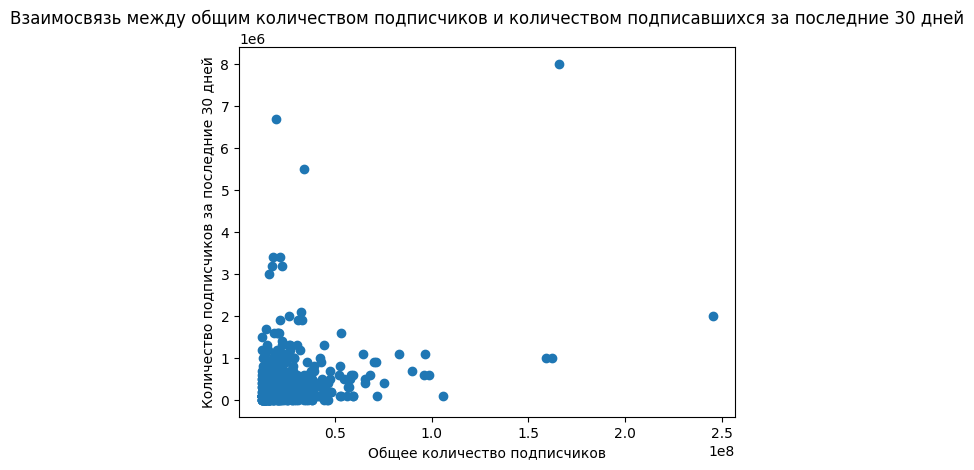

In [ ]:
x= df['subscribers']
y= df['subscribers_for_last_30_days']
plt.title('Взаимосвязь между общим количеством подписчиков и количеством подписавшихся за последние 30 дней')
plt.scatter(x, y)
plt.xlabel('Общее количество подписчиков')
plt.ylabel('Количество подписчиков за последние 30 дней')
plt.show()

In [ ]:
df[['subscribers', 'subscribers_for_last_30_days']].corr()

,subscribers,subscribers_for_last_30_days
subscribers,1.000000,0.309527
subscribers_for_last_30_days,0.309527,1.000000


#### Связан ли уровень безработицы с наличием высшего образования

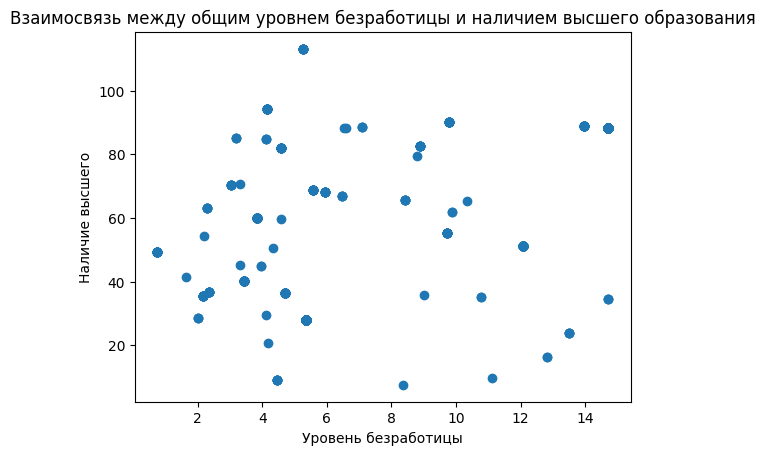

In [ ]:
x= df['Unemployment rate']
y= df['Gross tertiary education enrollment (%)']
plt.title('Взаимосвязь между общим уровнем безработицы и наличием высшего образования')
plt.scatter(x, y)
plt.xlabel('Уровень безработицы')
plt.ylabel('Наличие высшего')
plt.show()

In [ ]:
df[['Unemployment rate', 'Gross tertiary education enrollment (%)']].corr()

,Unemployment rate,Gross tertiary education enrollment (%)
Unemployment rate,1.000000,0.670979
Gross tertiary education enrollment (%),0.670979,1.000000


В данном случае мы видим среднее значение корреляции, однако, наличие корелляции не доказывает наличие причинно-следственной связи

### Больше всего каналов было создано в период c 2010 до 2015 года

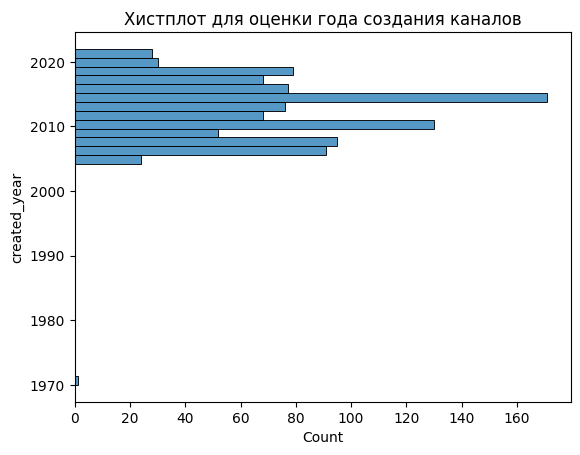

In [ ]:
sns.histplot(y=df['created_year'])
plt.title('Хистплот для оценки года создания каналов')
plt.show()

In [ ]:
print(df['created_year'].mode()[0])

2014.0


Действительно, большинство каналов было создано в 2014-м.

Так же, мы видим выброс в данных - один или несколько каналов созданы в 1970-м, при том что YouTube был запущен в феврале 2005-го

### Наибольшее количество просмотров имеет музыкальная категория

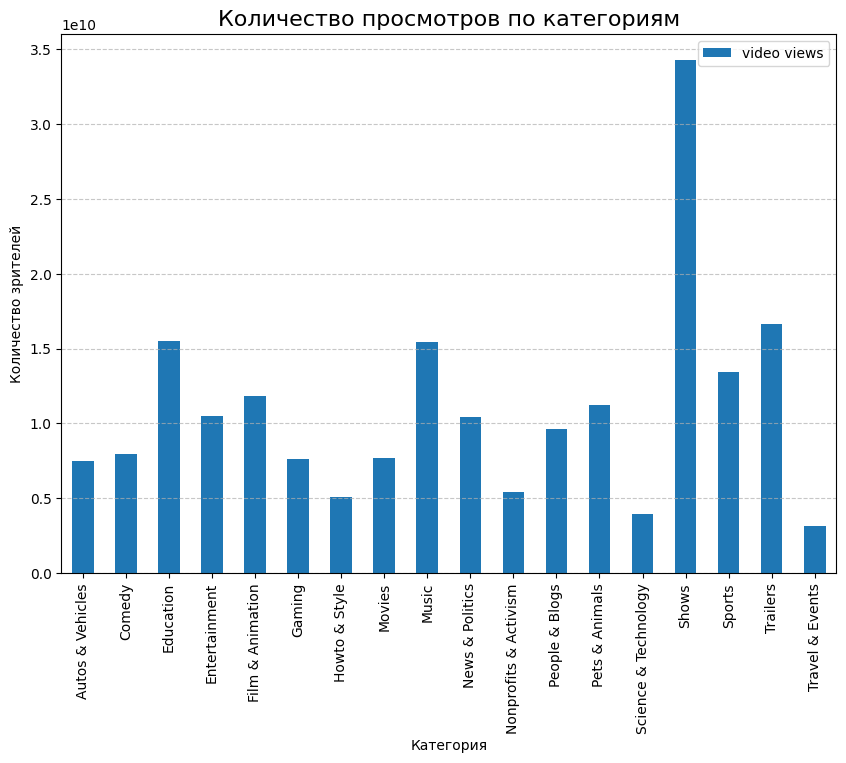

In [ ]:
views = df.groupby('category', observed=True)[['video views']].mean()

views.plot.bar(figsize=(10, 7), rot=0)
plt.title('Количество просмотров по категориям', fontsize=16)
plt.xlabel('Категория')
plt.xticks(rotation=90)
plt.ylabel('Количество зрителей')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Наибольшее количество подписчиков имеет категория 'Shows'

### Количество подписчиков в категории 'Pets & Animals' больше, чем в 'Howto & Style'

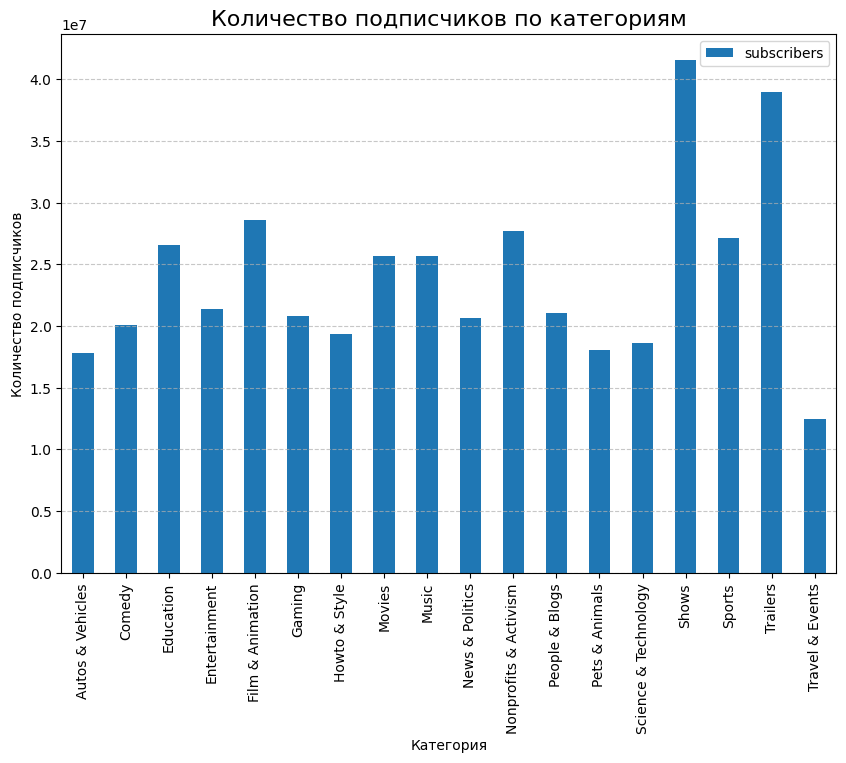

In [ ]:
subscribers = df.groupby('category', observed=True)[['subscribers']].mean()

subscribers.plot.bar(figsize=(10, 7), rot=0)
plt.title('Количество подписчиков по категориям', fontsize=16)
plt.xlabel('Категория')
plt.xticks(rotation=90)
plt.ylabel('Количество подписчиков')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Несмотря на большее количество просмотров, категория 'Pets & Animals' имеет меньшее количество подписчиков, чем категория 'Howto & Style'

### Связано ли количество просмотров видео с количеством загрузок видео

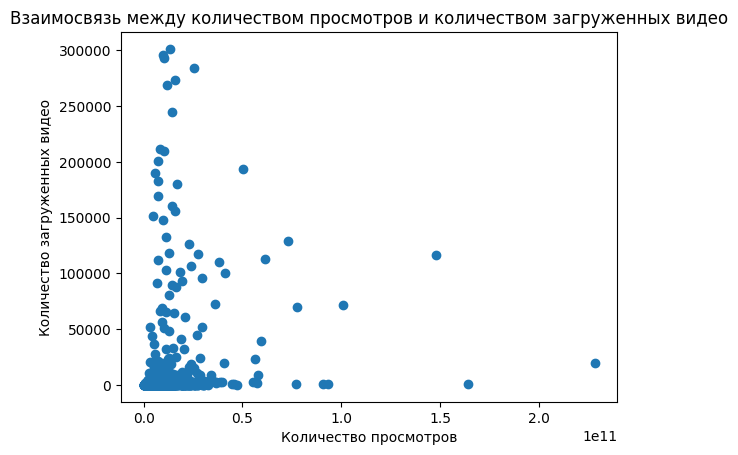

In [ ]:
x= df['video views']
y= df['uploads']
plt.title('Взаимосвязь между количеством просмотров и количеством загруженных видео')
plt.scatter(x, y)
plt.xlabel('Количество просмотров')
plt.ylabel('Количество загруженных видео')
plt.show()

In [ ]:
df[['video views', 'uploads']].corr()

,video views,uploads
video views,1.000000,0.165928
uploads,0.165928,1.000000


## Матрица корреляций

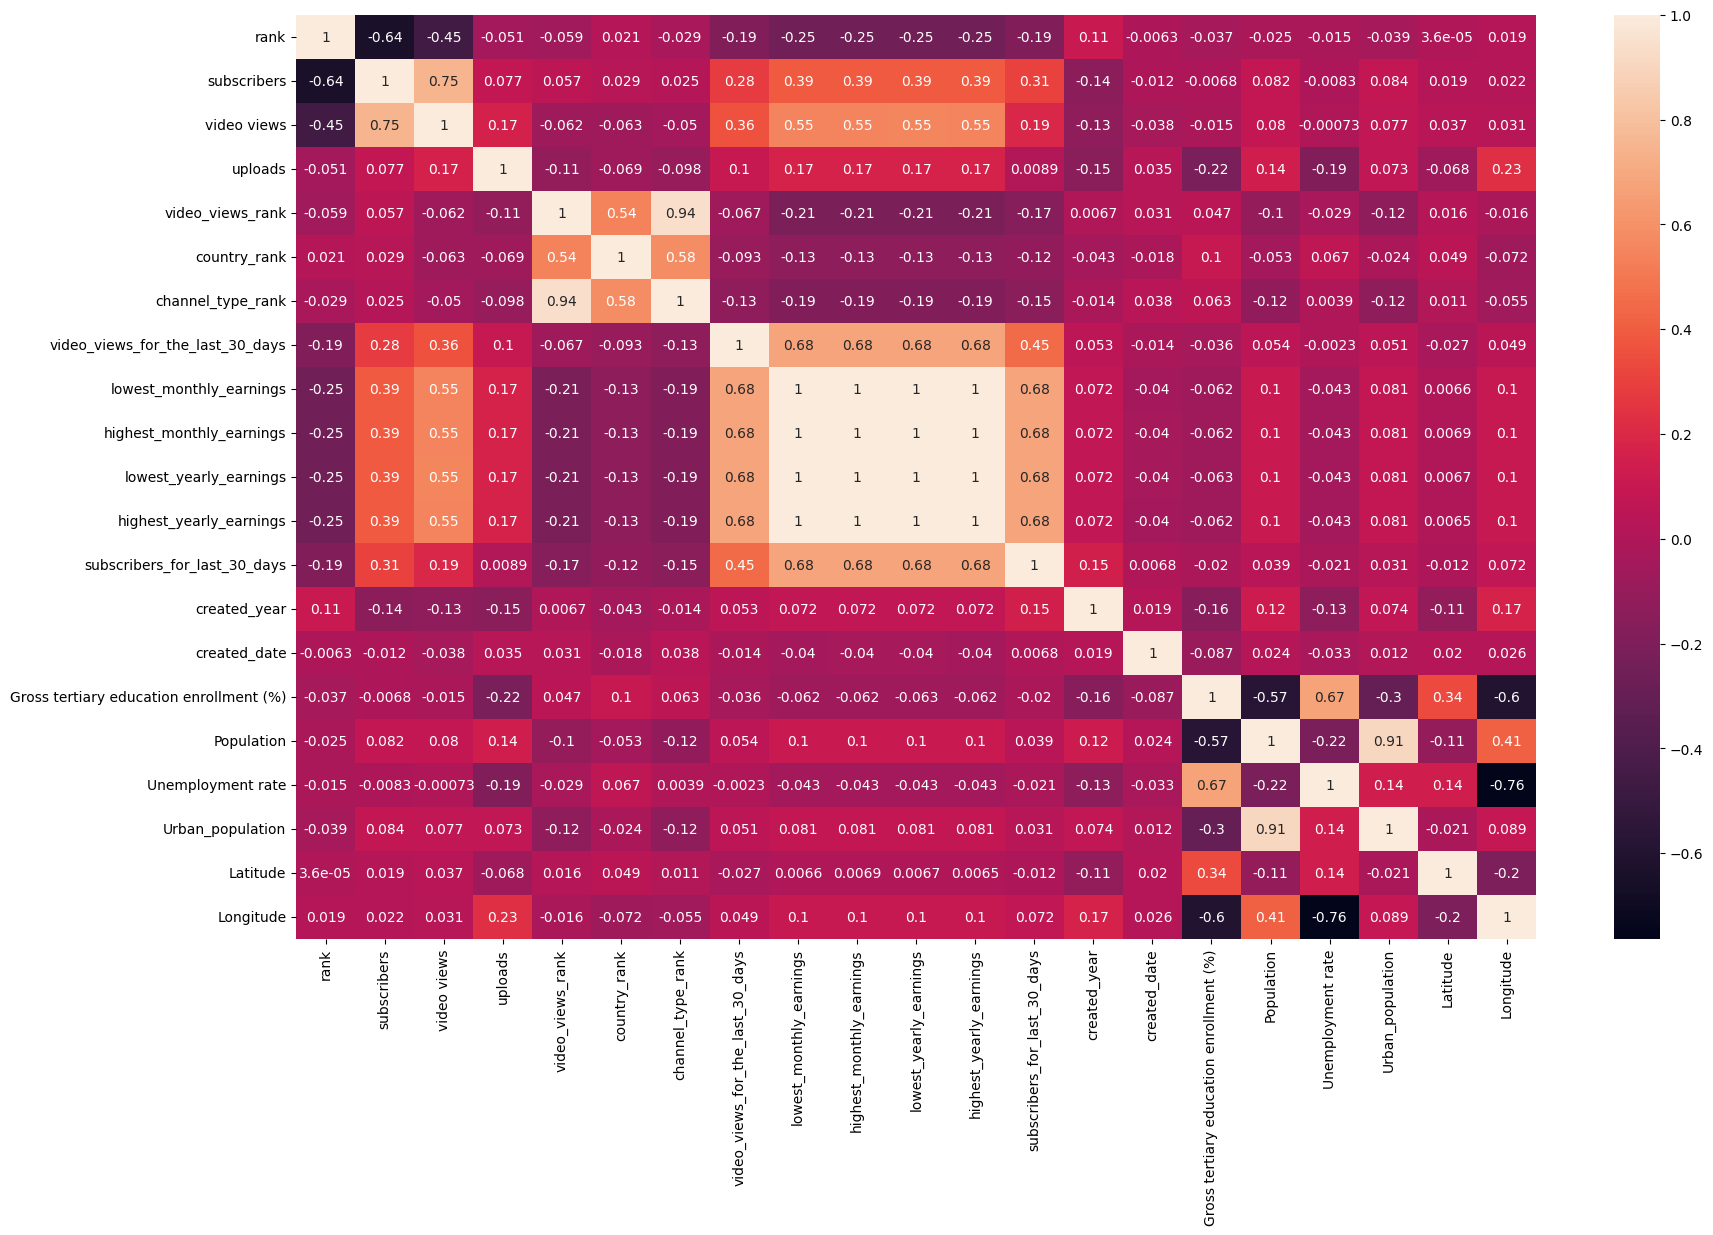

In [ ]:
df_heatmap = df.drop(['Youtuber', 'category', 'Title', 'Country', 'Abbreviation',
                      'channel_type', 'created_month'], axis=1)
plt.figure(figsize=(20, 12))
sns.heatmap(df_heatmap.corr(),  annot=True)
plt.show()

#**Задание 2. Корреляционный анализ**

1. Оставьте два коррелирующих столбца: "subscribers" и"video views".
2. Отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
3. Рассчитайте коэффициент корреляции Пирсона.
4. Определите "video views" как признак Х, а "subscribers" - как целевую переменную.
5. Разделите выборку на тестовую и тренировочную.
6. Постройте модель линейной регрессии.
7. Рассчитайте точность модели на тестовой выборке.

Как изменится точность, если опустить пункт 2 и не убирать из данных нулевые просмотры?

In [ ]:
df1 = df[['subscribers', 'video views']]
df1

,subscribers,video views
0,245000000,2.280000e+11
1,170000000,0.000000e+00
2,166000000,2.836884e+10
3,162000000,1.640000e+11
4,159000000,1.480000e+11
...,...,...
990,12300000,9.029610e+09
991,12300000,1.674410e+09
992,12300000,2.214684e+09
993,12300000,3.741235e+08


In [ ]:
df1 = df1.drop(df1[df1['video views'] == 0].index)

In [ ]:
df1

,subscribers,video views
0,245000000,2.280000e+11
2,166000000,2.836884e+10
3,162000000,1.640000e+11
4,159000000,1.480000e+11
6,112000000,9.324704e+10
...,...,...
990,12300000,9.029610e+09
991,12300000,1.674410e+09
992,12300000,2.214684e+09
993,12300000,3.741235e+08


In [ ]:
# По умолчанию данный метод позвращает коэффициент Пирсона
df1[['subscribers', 'video views']].corr()

,subscribers,video views
subscribers,1.000000,0.824262
video views,0.824262,1.000000


## Модель линейной регрессии

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# Напоминание для себя - Х с двумя квадратными скобками, мы передаем многомерный массив
X = df1[['video views']]
Y = df1['subscribers']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
model.coef_

array([0.00096569])

In [ ]:
model.intercept_

np.float64(11820073.18857631)

In [ ]:
Y_pred = model.predict(X_test)
Y_pred

array([2.01866830e+07, 2.77317948e+07, 1.40160689e+07, 1.50061073e+07,
       2.94036218e+07, 2.52600477e+07, 1.42437268e+07, 3.65489862e+07,
       3.84430600e+07, 2.10369262e+07, 3.23188093e+07, 3.05818764e+07,
       1.89763849e+07, 3.01308330e+07, 1.35361816e+07, 1.57484000e+07,
       1.62707178e+07, 3.17689688e+07, 5.51806063e+07, 1.38220277e+07,
       2.03976771e+07, 1.33391668e+07, 1.32751776e+07, 2.27211755e+07,
       1.19552920e+07, 1.36265085e+07, 1.34196997e+07, 1.28093957e+07,
       1.36902197e+07, 3.00887724e+07, 2.97004671e+07, 2.14044011e+07,
       1.81302338e+07, 1.47460036e+07, 1.33426185e+07, 1.81771725e+07,
       3.20218184e+07, 1.67393678e+07, 1.29290976e+07, 2.72847419e+07,
       2.10652823e+07, 4.03401401e+07, 3.96679341e+07, 1.85267875e+07,
       4.28619221e+07, 2.40118453e+07, 2.33564655e+07, 2.85352360e+07,
       1.62295486e+07, 1.76610914e+07, 1.50688908e+07, 1.61694445e+07,
       2.55320683e+07, 1.51476563e+07, 1.46284284e+07, 1.82389970e+07,
      

In [ ]:
Y_test

,subscribers
315,22300000
144,31700000
506,17600000
862,13300000
92,37600000
...,...
919,12900000
475,18100000
739,14500000
831,13600000


In [ ]:
# Коэффициент детерминации для определения точности модели
model.score(X_test, Y_test)

0.6631544237913568

Точность модели регрессии составила 66 процентов

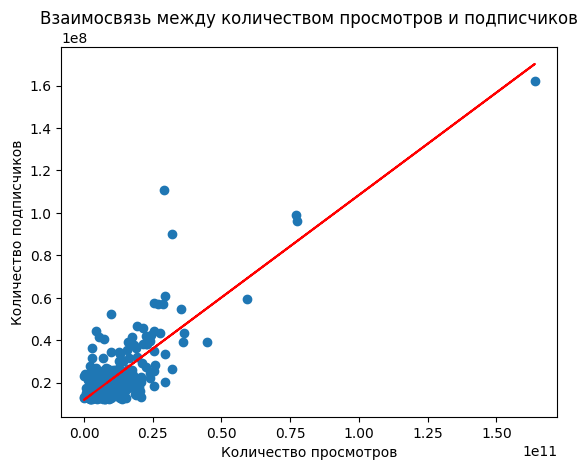

In [ ]:
plt.scatter(X_test, Y_test)
plt.title('Взаимосвязь между количеством просмотров и подписчиков')
plt.plot(X_test, Y_pred, c='r')
plt.xlabel('Количество просмотров')
plt.ylabel('Количество подписчиков')
plt.show()

<Axes: xlabel='subscribers', ylabel='Count'>

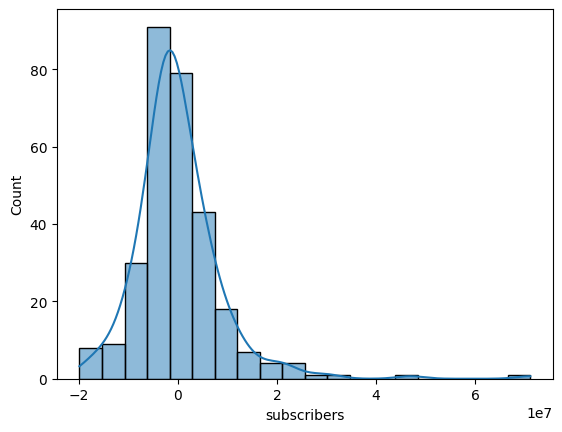

In [ ]:
# Остаточные значения
sns.histplot((Y_test - Y_pred), kde = True, bins = 20)

Распределение похоже на нормальное

Если не убирать нулевые значения из выборки, они могут негативно повлиять на точность модели, в данном случае точность модели уменьшится

Посмотрим на практике

In [ ]:
df2 = df[['subscribers', 'video views']]

In [ ]:
# Уже видим, что коэфф Пирсона уменьшился, если не чистить данные от нулей
df2[['subscribers', 'video views']].corr()

,subscribers,video views
subscribers,1.000000,0.750958
video views,0.750958,1.000000


In [ ]:
# Построим модель линейной регрессии
X = df2[['video views']]
Y = df2['subscribers']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [ ]:
model1 = LinearRegression()
model1.fit(X_train, Y_train)

LinearRegression()

In [ ]:
model1.score(X_test, Y_test)

0.3401071411772094

Точность модели уменьшилась практически в два раза

#**Задание 3. Классификация**

* Определите две самые популярные категории канала и отфильтруйте по ним набор данных.
* В качестве признаков используйте следующие столбцы: [‘video views’, ‘subscribers’, ‘uploads’]
* Снова отфильтруйте данные - уберите те строки, где кол-во просмотров равно нулю.
* Для целевой переменной используйте столбец'category'. Значения по нему закодируйте с помощью LabelEncoder.
* Разделите выборку на тестовую и тренировочную, укажите random_state=13.`
* Постройте модель логистической регрессии.
* Рассчитайте точность модели на тестовой выборке.
Изменится ли точность модели, если в качестве признаков выбрать другие столбцы?

## Сделаем по количеству каналов в категории

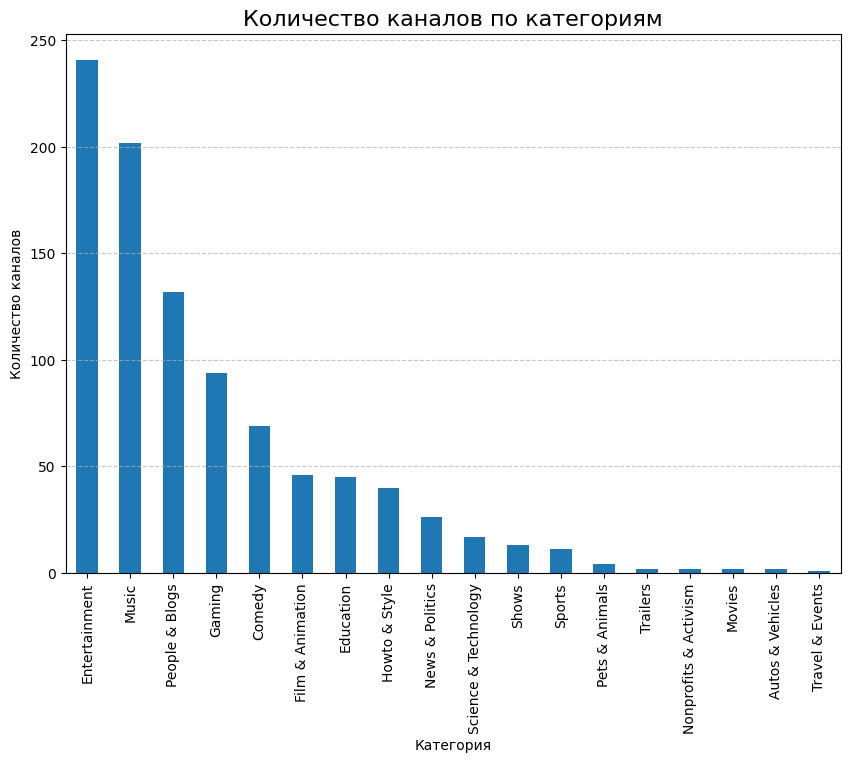

In [ ]:
# Посмотрим количество каналов в каждой категории, визуализируем
category = df['category'].value_counts()

category.plot.bar(figsize=(10, 7), rot=0)
plt.title('Количество каналов по категориям', fontsize=16)
plt.xlabel('Категория')
plt.xticks(rotation = 90)
plt.ylabel('Количество каналов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Самыми популярными категориями по количеству созданных каналов являются 'Entertainment' и 'Music'

In [ ]:
# Отфильтруем по категориям
df_filtred = df[(df['category'] == 'Entertainment') | (df['category'] == 'Music')]
df_filtred

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
9,10,Vlad and Niki,98900000,7.718017e+10,Entertainment,Vlad and Niki,574,United States,US,Entertainment,...,600000.0,2018.0,Apr,23.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
10,11,Zee Music Company,96700000,5.785629e+10,Music,Zee Music Company,8548,India,IN,Music,...,1100000.0,2014.0,Mar,12.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
17,18,BANGTANTV,75600000,2.082699e+10,Music,BANGTANTV,2281,South Korea,KR,Music,...,400000.0,2012.0,Dec,17.0,94.3,5.170910e+07,4.15,42106719.0,35.907757,127.766922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,977,SAAIHALILINTAR,12400000,1.113066e+09,Entertainment,SAAIHALILINTAR,409,Indonesia,ID,Entertainment,...,NaN,2012.0,Apr,28.0,36.3,2.702039e+08,4.69,151509724.0,-0.789275,113.921327
978,979,Heidi and Zidane HZHtube,12400000,4.021409e+09,Entertainment,Heidi and Zidane HZHtube,813,Canada,CA,Entertainment,...,NaN,2015.0,Nov,24.0,68.9,3.699198e+07,5.56,30628482.0,56.130366,-106.346771
982,983,DisneyChannelUK,12400000,1.260749e+10,Music,DisneyChannelUK,4422,United Kingdom,GB,Entertainment,...,NaN,2007.0,Dec,6.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
987,988,Avril Lavigne,12400000,6.202090e+09,Music,Avril Lavigne,205,United States,US,Music,...,NaN,2005.0,Oct,8.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891


In [ ]:
# Дропнем каналы с нулевыми просмотрами или загрузками
data = df_filtred.drop(df_filtred[df_filtred['video views'] == 0].index)
data = df_filtred.drop(df_filtred[df_filtred['uploads'] == 0].index)

In [ ]:
data = data[['category', 'video views', 'subscribers', 'uploads']]
data

,category,video views,subscribers,uploads
0,Music,2.280000e+11,245000000,20082
2,Entertainment,2.836884e+10,166000000,741
9,Entertainment,7.718017e+10,98900000,574
10,Music,5.785629e+10,96700000,8548
17,Music,2.082699e+10,75600000,2281
...,...,...,...,...
976,Entertainment,1.113066e+09,12400000,409
978,Entertainment,4.021409e+09,12400000,813
982,Music,1.260749e+10,12400000,4422
987,Music,6.202090e+09,12400000,205


## Строим и обучаем модель

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [ ]:
# Закодируем категории
le = LabelEncoder()
data['category'] = le.fit_transform(data['category'])

In [ ]:
data

,category,video views,subscribers,uploads
0,1,2.280000e+11,245000000,20082
2,0,2.836884e+10,166000000,741
9,0,7.718017e+10,98900000,574
10,1,5.785629e+10,96700000,8548
17,1,2.082699e+10,75600000,2281
...,...,...,...,...
976,0,1.113066e+09,12400000,409
978,0,4.021409e+09,12400000,813
982,1,1.260749e+10,12400000,4422
987,1,6.202090e+09,12400000,205


In [ ]:
# Logistic Regression
X = data[['video views', 'subscribers', 'uploads']]
Y = data['category']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=13, stratify=Y)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(random_state=13)

In [ ]:
model.fit(X_train, Y_train)

LogisticRegression(random_state=13)

In [ ]:
lr_predictions = model.predict(X_test)
print(classification_report(Y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.76      0.79      0.78        57
           1       0.74      0.71      0.73        49

    accuracy                           0.75       106
   macro avg       0.75      0.75      0.75       106
weighted avg       0.75      0.75      0.75       106



Text(50.722222222222214, 0.5, 'Факт')

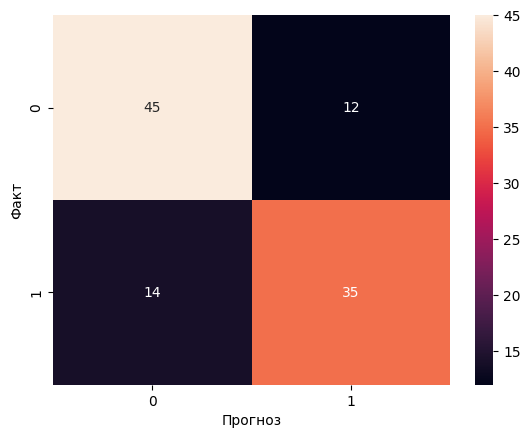

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, lr_predictions)
sns.heatmap(cm, annot=True, fmt='')
plt.xlabel('Прогноз')
plt.ylabel('Факт')

Попробуем в Downsampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=13)

X_train_down, Y_train_down = rus.fit_resample(X_train, Y_train)

In [ ]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_down, Y_train_down)

lr_predictions = lr_model.predict(X_test)

print(classification_report(Y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.79      0.72      0.75        57
           1       0.70      0.78      0.74        49

    accuracy                           0.75       106
   macro avg       0.75      0.75      0.75       106
weighted avg       0.75      0.75      0.75       106



Text(50.722222222222214, 0.5, 'Факт')

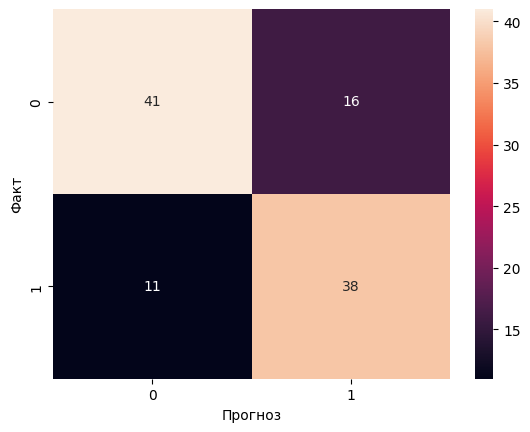

In [ ]:
# Визуализируем
cm = confusion_matrix(Y_test, lr_predictions)
sns.heatmap(cm, annot=True, fmt='')
plt.xlabel('Прогноз')
plt.ylabel('Факт')

Точность модели, вероятно, именится при выборе других признаков. Как минимум при увеличении признаков может возникнуть ложная зависимость, признаки могут быть скореллированы и т.д.